warm-up ...
n=  1,500  density-based  median=   0.117s  min=   0.117s  max=   0.123s
n=  1,500       standard  median=   0.057s  min=   0.057s  max=   0.059s
n=  3,000  density-based  median=   0.211s  min=   0.210s  max=   0.216s
n=  3,000       standard  median=   0.093s  min=   0.090s  max=   0.097s
n=  6,000  density-based  median=   0.431s  min=   0.429s  max=   0.437s
n=  6,000       standard  median=   0.182s  min=   0.180s  max=   0.189s
n= 12,000  density-based  median=   1.011s  min=   1.008s  max=   1.014s
n= 12,000       standard  median=   0.421s  min=   0.418s  max=   0.424s
n= 24,000  density-based  median=   2.748s  min=   2.730s  max=   2.761s
n= 24,000       standard  median=   1.187s  min=   1.181s  max=   1.194s
n= 48,000  density-based  median=   8.730s  min=   8.712s  max=   8.800s
n= 48,000       standard  median=   4.086s  min=   4.073s  max=   4.107s

density-based:  T ~ 1.379e-06 * n^1.446   (R^2=0.9954, stderr(alpha)=0.069, fit on n>=6,000)
                ro

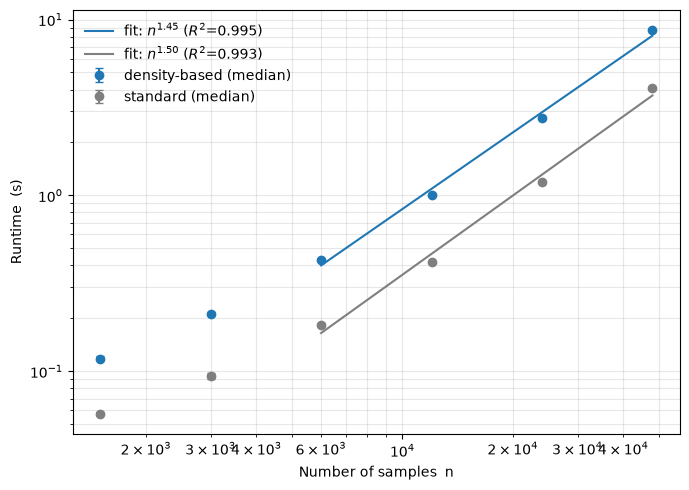


phase-by-phase breakdown (density-based, seconds)
-------------------------------------------------------------------------------------------------
phase                       1,500    3,000    6,000   12,000   24,000   48,000   ~expshare@48,000
-------------------------------------------------------------------------------------------------
clustering (per slice)      0.013    0.030    0.095    0.359    1.453    6.139   1.79       70.3%
density Python loops        0.036    0.073    0.146    0.293    0.570    1.135   0.99       13.0%
cover / kernel weights      0.022    0.045    0.091    0.180    0.354    0.714   1.00        8.2%
kNN search                  0.011    0.023    0.051    0.104    0.226    0.478   1.08        5.5%
adjacency matrix            0.007    0.014    0.028    0.055    0.108    0.213   0.99        2.4%
add vertices                0.000    0.000    0.001    0.001    0.001    0.003   0.57        0.0%
add edges                   0.002    0.001    0.001    0.001    0.0

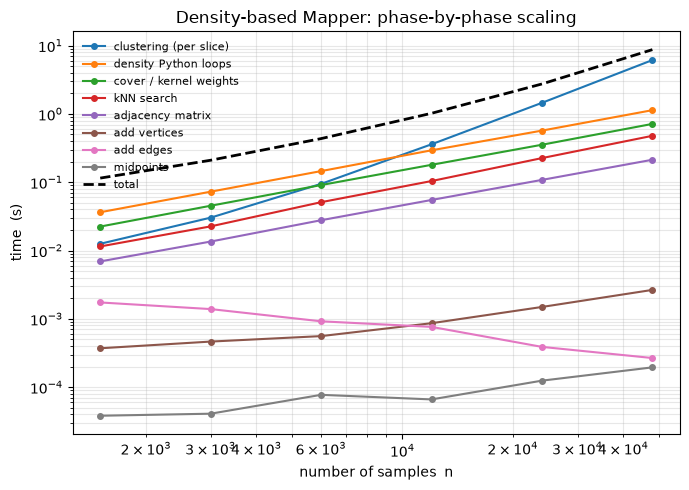

In [3]:
"""
Author's note: This file was originally generated by an LLM (Claude 4.8 Opus)
before human review + modifications.

====================================================================
Empirical runtime scaling of density-based Mapper (temporal-mapper).
====================================================================

Measures wall-clock time of `TemporalMapper.fit` as a function of the number of
samples n, fits a power law T(n) = C * n**alpha to recover an empirical scaling
exponent, and reports a per-phase time breakdown so you can see
which part of the algorithm dominates and how each phase scales.

Methodology
  * A SINGLE generating distribution (fixed support, fixed density profile) is
    used for every n; only the sample count changes, isolating the n-dependence.
    The temporal density is non-uniform, so the density estimator is exercised.
  * Every algorithm parameter is held constant across n.
  * Only `mapper.fit(...)` is timed. A warm-up fit is run and discarded.
  * Each n is repeated N_REPS times; the median feeds the fit, min/max give the
    error band. The power law is fit in log-log space on n >= FIT_MIN_N (small n
    sits in a fixed-overhead regime that biases alpha down); a 3-parameter
    T = C*n**alpha + b model is also reported.

Requires: temporal-mapper, scikit-learn, numpy, matplotlib, scipy.
"""

import gc
import time
import warnings
import contextlib

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering

import temporalmapper as tm
from temporalmapper import kernels

# ----------------------------------------------------------------------------
# CONFIG
# ----------------------------------------------------------------------------
SIZES = [1_500, 3_000, 6_000, 12_000, 24_000, 48_000]  # geometric (doubling)
N_REPS = 4                 # repetitions per size (median used for the fit)
WARMUP = True              # run + discard one fit before timing
SEED = 0

# --- mapper parameters, held FIXED across all n ---
N_SLICES = 10              # N in the paper
N_NEIGHBORS = 50           # k for the density estimate; keep < min slice size
OVERLAP = 0.8              # g
KERNEL = kernels.square    # matches the paper's UNGDC run (no epsilon dependence)
DISTANCE_THRESHOLD = 0.2   # single-linkage cut; tune to your data's length scale
SLICE_METHOD = "time"      # lens-spaced cover (valid under smooth variable density)

COMPARE_STANDARD = True    # also time density_based=False for the overhead comparison
FIT_MIN_N = 6_000          # exclude smaller sizes from the power-law fit
PROFILE_PHASES = True      # measure + report the per-phase time breakdown
SUPPRESS_WARNINGS = True   # silence harmless cover/numba warnings (nice in notebooks)

OUT_PNG = "dbmapper_runtime_scaling.png"
OUT_PHASE_PNG = "dbmapper_phase_breakdown.png"


# ----------------------------------------------------------------------------
# Warning suppression (scoped to the fits; controlled by SUPPRESS_WARNINGS)
# ----------------------------------------------------------------------------
@contextlib.contextmanager
def _maybe_silence():
    if SUPPRESS_WARNINGS:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            yield
    else:
        yield

if SUPPRESS_WARNINGS:
    # also quiet the known, harmless temporal-mapper cover warnings if any fire
    # outside the timed sections (does not blanket-hide other warnings)
    for _msg in (".*is empty.*", ".*do not form a cover.*"):
        warnings.filterwarnings("ignore", message=_msg)


# ----------------------------------------------------------------------------
# Synthetic data: fixed shape, variable temporal density, two components
# (one a ring / genus-1 feature, one a blob) drifting over time.
# ----------------------------------------------------------------------------
def generate_data(n, seed=0):
    rng = np.random.default_rng(seed)

    # Smooth, non-uniform temporal density (skewed Beta) with no discontinuity,
    # which keeps the kerneled cover valid. (A sharp density jump, or the
    # data-spaced cover in a high-density region, can empty a slice -- the
    # documented failure mode in the paper's remark after the data-spaced cover.)
    t = rng.beta(2.0, 4.0, size=n)

    topic = rng.integers(0, 2, size=n)
    x = np.empty(n)
    y = np.empty(n)

    # Topic 0: ring (loop) whose centre drifts along x with time.
    m0 = topic == 0
    theta = rng.uniform(0, 2 * np.pi, size=m0.sum())
    r = 1.0 + rng.normal(0, 0.05, size=m0.sum())
    x[m0] = 4.0 * t[m0] - 2.0 + r * np.cos(theta)
    y[m0] = r * np.sin(theta)

    # Topic 1: Gaussian blob drifting the opposite way.
    m1 = topic == 1
    x[m1] = -4.0 * t[m1] + 2.0 + rng.normal(0, 0.30, size=m1.sum())
    y[m1] = 3.0 + rng.normal(0, 0.30, size=m1.sum())

    X = np.column_stack([t, x, y])          # feature 0 = time (Morse-type fn)
    X = X[np.argsort(X[:, 0])]              # sort by time, as in the quickstart
    return X


def make_clusterer():
    # Fresh estimator per fit: sklearn estimators are stateful once fit.
    # ---- swap the clusterer here ----
    return AgglomerativeClustering(
        linkage="single", distance_threshold=DISTANCE_THRESHOLD, n_clusters=None,
    )
    # Near-linear alternative (Leland's boruvka MST); flattens total to ~n^1.0:
    #   from fast_hdbscan import HDBSCAN
    #   return HDBSCAN(min_cluster_size=15)
    # sklearn's HDBSCAN (still ~O(m^2) per slice in this regime):
    #   from sklearn.cluster import HDBSCAN
    #   return HDBSCAN(min_cluster_size=15)


def _make_mapper(density_based):
    return tm.TemporalMapper(
        clusterer=make_clusterer(),
        n_slices=N_SLICES, n_neighbors=N_NEIGHBORS, overlap=OVERLAP,
        slice_method=SLICE_METHOD, kernel=KERNEL, density_based=density_based,
    )


def time_fit(X, density_based, reps):
    times = []
    for _ in range(reps):
        mapper = _make_mapper(density_based)
        gc.collect()
        with _maybe_silence():
            t0 = time.perf_counter()
            mapper.fit(X, time_index=0)
            times.append(time.perf_counter() - t0)
    return times


# ----------------------------------------------------------------------------
# Per-phase profiling (optional)
# ----------------------------------------------------------------------------
# Internal Mapper methods, in execution order. `_compute_knn` is called inside
# `_compute_density`; we report the remainder as "density Python loops".
_PHASE_METHODS = ["_compute_midpoints", "_compute_knn", "_compute_density",
                  "_compute_weights", "_cluster", "_add_vertices",
                  "_build_adjacency_matrix", "_add_edges"]

# What we actually display (mutually exclusive, sums to ~TOTAL):
_DISPLAY = ["_cluster", "_density_pyloops", "_compute_weights", "_compute_knn",
            "_build_adjacency_matrix", "_add_vertices", "_add_edges",
            "_compute_midpoints"]

_PHASE_LABELS = {
    "_cluster": "clustering (per slice)",
    "_density_pyloops": "density Python loops",
    "_compute_weights": "cover / kernel weights",
    "_compute_knn": "kNN search",
    "_build_adjacency_matrix": "adjacency matrix",
    "_add_vertices": "add vertices",
    "_add_edges": "add edges",
    "_compute_midpoints": "midpoints",
    "TOTAL": "total",
}

_PHASE_ACC = {}
_PHASES_READY = False


def _install_phase_timers():
    """Monkeypatch Mapper methods with perf_counter accumulators (idempotent)."""
    global _PHASES_READY
    if _PHASES_READY:
        return True
    try:
        from temporalmapper.mapper import Mapper
    except Exception as e:               # internal layout changed: degrade gracefully
        print(f"[phase profiling unavailable: {e}]")
        return False

    def make_timed(orig, name):
        def timed(self, *a, **k):
            t0 = time.perf_counter()
            try:
                return orig(self, *a, **k)
            finally:
                _PHASE_ACC[name] = _PHASE_ACC.get(name, 0.0) + (time.perf_counter() - t0)
        timed._phase_wrapped = True
        return timed

    for name in _PHASE_METHODS:
        orig = getattr(Mapper, name, None)
        if orig is None or getattr(orig, "_phase_wrapped", False):
            continue                     # missing, or already wrapped (cell re-run)
        setattr(Mapper, name, make_timed(orig, name))
    _PHASES_READY = True
    return True


def profile_fit(X, density_based=True):
    """One instrumented fit. Returns {phase: seconds} incl. _density_pyloops, TOTAL."""
    global _PHASE_ACC
    _PHASE_ACC = {p: 0.0 for p in _PHASE_METHODS}
    mapper = _make_mapper(density_based)
    gc.collect()
    with _maybe_silence():
        t0 = time.perf_counter()
        mapper.fit(X, time_index=0)
        total = time.perf_counter() - t0
    out = dict(_PHASE_ACC)
    out["_density_pyloops"] = out.get("_compute_density", 0.0) - out.get("_compute_knn", 0.0)
    out["TOTAL"] = total
    return out


def _mean_exponent(sizes, vals):
    s = np.asarray(sizes, float)
    v = np.asarray(vals, float)
    ok = v > 0
    if ok.sum() < 2:
        return float("nan")
    return float(np.mean(np.diff(np.log(v[ok])) / np.diff(np.log(s[ok]))))


def _report_phases(rows):
    sizes = sorted(rows)
    maxn = sizes[-1]
    order = sorted(_DISPLAY, key=lambda c: rows[maxn].get(c, 0.0), reverse=True)
    print("\nphase-by-phase breakdown (density-based, seconds)")
    width = 24 + 9 * len(sizes) + 7 + 12
    print("-" * width)
    print(f"{'phase':<24}" + "".join(f"{n:>9,}" for n in sizes)
          + f"{'~exp':>7}" + f"{'share@'+format(maxn, ','):>12}")
    print("-" * width)
    for c in order:
        vals = [rows[n].get(c, 0.0) for n in sizes]
        if max(vals) <= 0:
            continue
        share = 100 * rows[maxn].get(c, 0.0) / rows[maxn]["TOTAL"]
        print(f"{_PHASE_LABELS.get(c, c):<24}" + "".join(f"{v:>9.3f}" for v in vals)
              + f"{_mean_exponent(sizes, vals):>7.2f}" + f"{share:>11.1f}%")
    tvals = [rows[n]["TOTAL"] for n in sizes]
    print("-" * width)
    print(f"{'total':<24}" + "".join(f"{v:>9.3f}" for v in tvals)
          + f"{_mean_exponent(sizes, tvals):>7.2f}" + f"{'100.0%':>12}")


def _plot_phases(rows):
    sizes = np.array(sorted(rows), float)
    maxn = sorted(rows)[-1]
    order = sorted(_DISPLAY, key=lambda c: rows[maxn].get(c, 0.0), reverse=True)
    fig, ax = plt.subplots(figsize=(7, 5))
    for c in order:
        vals = np.array([rows[n].get(c, 0.0) for n in sorted(rows)])
        if vals.max() <= 0:
            continue
        ax.plot(sizes, vals, "o-", ms=4, label=_PHASE_LABELS.get(c, c))
    ax.plot(sizes, [rows[n]["TOTAL"] for n in sorted(rows)],
            "k--", lw=2, label="total")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("number of samples  n")
    ax.set_ylabel("time  (s)")
    ax.set_title("Density-based Mapper: phase-by-phase scaling")
    ax.legend(frameon=False, fontsize=8)
    ax.grid(True, which="both", alpha=0.3)
    fig.tight_layout()
    fig.savefig(OUT_PHASE_PNG, dpi=150)
    print(f"saved {OUT_PHASE_PNG}")
    plt.show()


# ----------------------------------------------------------------------------
# Power-law fitting
# ----------------------------------------------------------------------------
def fit_powerlaw_loglog(ns, ts):
    """OLS in log-log space -> T = C * n**alpha. Returns alpha, C, R^2, stderr(alpha)."""
    from scipy import stats
    res = stats.linregress(np.log(ns), np.log(ts))
    return res.slope, np.exp(res.intercept), res.rvalue ** 2, res.stderr


def fit_powerlaw_offset(ns, ts):
    """3-parameter robustness check: T = C * n**alpha + b. Returns (C, alpha, b), stderrs."""
    from scipy.optimize import curve_fit
    f = lambda n, C, a, b: C * np.power(n, a) + b
    p0 = [ts[-1] / ns[-1] ** 1.5, 1.5, 0.0]
    with _maybe_silence():
        popt, pcov = curve_fit(f, ns, ts, p0=p0, maxfev=20000)
    return popt, np.sqrt(np.diag(pcov))


# ----------------------------------------------------------------------------
# Run
# ----------------------------------------------------------------------------
def run():
    modes = [True, False] if COMPARE_STANDARD else [True]
    labels = {True: "density-based", False: "standard"}
    results = {m: {} for m in modes}

    if WARMUP:
        print("warm-up ...")
        _ = time_fit(generate_data(SIZES[0], seed=SEED), density_based=True, reps=1)

    for n in SIZES:
        X = generate_data(n, seed=SEED)
        for m in modes:
            ts = time_fit(X, density_based=m, reps=N_REPS)
            results[m][n] = ts
            print(f"n={n:>7,}  {labels[m]:>13}  median={np.median(ts):8.3f}s"
                  f"  min={np.min(ts):8.3f}s  max={np.max(ts):8.3f}s")

    # --- scaling fit ---
    fits = {}
    print("\n" + "=" * 64)
    for m in modes:
        ns = np.array(SIZES, float)
        med = np.array([np.median(results[m][n]) for n in SIZES])
        mask = ns >= FIT_MIN_N
        alpha, C, r2, se = fit_powerlaw_loglog(ns[mask], med[mask])
        fits[m] = (alpha, C, r2, se)
        print(f"{labels[m]:>13}:  T ~ {C:.3e} * n^{alpha:.3f}   "
              f"(R^2={r2:.4f}, stderr(alpha)={se:.3f}, fit on n>={FIT_MIN_N:,})")
        try:
            (C2, a2, b2), perr = fit_powerlaw_offset(ns, med)
            print(f"{'':>13}   robustness  T ~ {C2:.3e}*n^{a2:.3f} + {b2:.3f}"
                  f"   (alpha={a2:.3f} +/- {perr[1]:.3f}, all n)")
        except Exception as e:
            print(f"{'':>13}   offset fit skipped ({e})")
    print("=" * 64)

    # --- scaling plot ---
    fig, ax = plt.subplots(figsize=(7, 5))
    colors = {True: "tab:blue", False: "tab:grey"}
    for m in modes:
        ns = np.array(SIZES, float)
        med = np.array([np.median(results[m][n]) for n in SIZES])
        lo = np.array([np.min(results[m][n]) for n in SIZES])
        hi = np.array([np.max(results[m][n]) for n in SIZES])
        ax.errorbar(ns, med, yerr=[med - lo, hi - med], fmt="o",
                    color=colors[m], capsize=3, label=f"{labels[m]} (median)")
        alpha, C, r2, _ = fits[m]
        xx = np.linspace(FIT_MIN_N, ns.max(), 100)
        ax.plot(xx, C * xx ** alpha, "-", color=colors[m],
                label=fr"fit: $n^{{{alpha:.2f}}}$ ($R^2$={r2:.3f})")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Number of samples  n")
    ax.set_ylabel("Runtime  (s)")
    #ax.set_title("Density-based Mapper runtime scaling")
    ax.legend(frameon=False)
    ax.grid(True, which="both", alpha=0.3)
    fig.tight_layout()
    fig.savefig(OUT_PNG, dpi=150)
    print(f"\nsaved {OUT_PNG}")
    plt.show()

    # --- per-phase breakdown ---
    phase_rows = None
    if PROFILE_PHASES and _install_phase_timers():
        phase_rows = {}
        profile_fit(generate_data(SIZES[0], seed=SEED))      # warm (numba/caches)
        for n in SIZES:
            phase_rows[n] = profile_fit(generate_data(n, seed=SEED), density_based=True)
        _report_phases(phase_rows)
        _plot_phases(phase_rows)

    return results, fits, phase_rows


if __name__ == "__main__":
    run()


########## clusterer: single-linkage ##########
  n=  1,500  density-based  median=   0.116s  min=   0.115s  max=   0.118s
  n=  1,500       standard  median=   0.056s  min=   0.056s  max=   0.057s
  n=  3,000  density-based  median=   0.209s  min=   0.208s  max=   0.215s
  n=  3,000       standard  median=   0.093s  min=   0.092s  max=   0.094s
  n=  6,000  density-based  median=   0.431s  min=   0.428s  max=   0.446s
  n=  6,000       standard  median=   0.182s  min=   0.181s  max=   0.186s
  n= 12,000  density-based  median=   1.014s  min=   1.009s  max=   1.037s
  n= 12,000       standard  median=   0.420s  min=   0.417s  max=   0.422s
  n= 24,000  density-based  median=   2.738s  min=   2.731s  max=   2.746s
  n= 24,000       standard  median=   1.185s  min=   1.179s  max=   1.186s
  n= 48,000  density-based  median=   8.718s  min=   8.712s  max=   8.744s
  n= 48,000       standard  median=   4.069s  min=   4.054s  max=   4.080s
  -------------------------------------------------

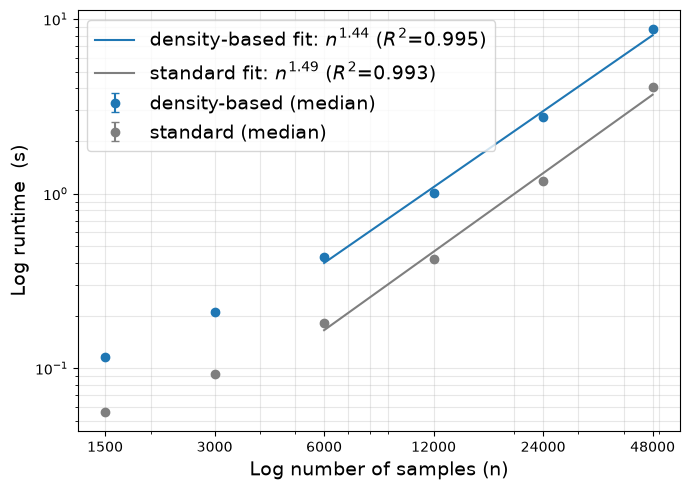


% share of runtime by phase -- single-linkage (density-based Mapper)
----------------------------------------------------------------------------
phase                     1,500    3,000    6,000   12,000   24,000   48,000
----------------------------------------------------------------------------
clustering                11.3%    14.3%    22.0%    35.4%    53.1%    70.3%
density Python loops      31.4%    34.9%    33.3%    28.0%    20.7%    13.0%
construct cover           19.7%    21.3%    20.8%    17.5%    12.8%     8.2%
kNN search                 9.9%    10.8%    11.4%    10.4%     8.2%     5.5%
construct graph            7.7%     7.3%     7.0%     5.9%     4.0%     2.5%
----------------------------------------------------------------------------
total (s)                  0.12     0.21     0.43     1.01     2.73     8.77

########## clusterer: fast_hdbscan ##########
  n=  1,500  density-based  median=   0.093s  min=   0.092s  max=   0.095s
  n=  1,500       standard  median=   

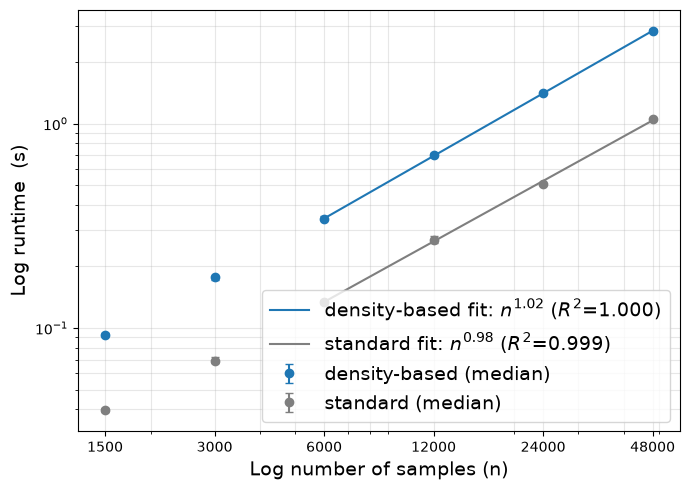


% share of runtime by phase -- fast_hdbscan (density-based Mapper)
----------------------------------------------------------------------------
phase                     1,500    3,000    6,000   12,000   24,000   48,000
----------------------------------------------------------------------------
density Python loops      39.4%    42.0%    42.3%    41.7%    40.0%    40.0%
construct cover           23.6%    25.5%    25.9%    25.8%    25.5%    25.1%
kNN search                12.4%    13.1%    14.5%    15.0%    15.6%    17.0%
clustering                14.6%    10.2%     9.3%     9.0%    10.3%     9.6%
construct graph            3.9%     5.4%     4.4%     5.4%     6.5%     7.0%
----------------------------------------------------------------------------
total (s)                  0.10     0.17     0.34     0.70     1.43     2.82


In [ ]:
"""
Empirical runtime scaling of density-based Mapper (temporal-mapper).
====================================================================

For each clusterer (single-linkage AgglomerativeClustering and Leland's
fast_hdbscan) this produces:

  * a scaling FIGURE: fit time vs n for standard Mapper and density-based Mapper,
    each with an empirical power-law fit  T(n) = C * n**alpha.
      -> dbmapper_scaling_single_linkage.png
      -> dbmapper_scaling_fast_hdbscan.png
  * a phase TABLE: % share of runtime per phase at each n (density-based Mapper),
    printed to the console.

Phases are grouped into:
  clustering            - per-slice clustering
  density Python loops  - the temporal-width + cosine-window post-processing
  kNN search            - the k-NN query for the density estimate
  construct cover       - midpoints + kerneled-cover/kernel-weight construction
  construct graph       - adjacency matrix + vertices + edges

Methodology
  * One generating distribution (fixed support, non-uniform temporal density) is
    used for every n; only the sample count changes, isolating the n-dependence.
  * All algorithm parameters are held constant across n. Only fit() is timed; a
    warm-up fit is discarded per clusterer (imports / numba JIT / caches).
  * Each n is repeated N_REPS times; the median feeds the fit, min/max give the
    error band. Power law fit in log-log space on n >= FIT_MIN_N; a 3-parameter
    T = C*n**alpha + b model is reported as a robustness check.

Clusterer note
  single-linkage and sklearn HDBSCAN are ~O(m^2) per slice in this regime, so
  total ~n^1.5 and clustering dominates. fast_hdbscan (boruvka MST) is
  ~near-linear per slice, flattening total to ~n^1.0 and moving the bottleneck
  onto the density step. Edit CLUSTERERS / the factories below to change this.

Requires: temporal-mapper, scikit-learn, numpy, matplotlib, scipy.
Optional:  fast_hdbscan (skipped automatically if not installed).
"""

import gc
import time
import warnings
import contextlib

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering

import temporalmapper as tm
from temporalmapper import kernels

# ----------------------------------------------------------------------------
# CONFIG
# ----------------------------------------------------------------------------
SIZES = [1_500, 3_000, 6_000, 12_000, 24_000, 48_000]  # geometric (doubling)
N_REPS = 4                 # repetitions per size (median used for the fit)
WARMUP = True              # run + discard one fit per clusterer before timing
SEED = 0

# --- mapper parameters, held FIXED across all n ---
N_SLICES = 10              # N in the paper
N_NEIGHBORS = 50           # k for the density estimate; keep < min slice size
OVERLAP = 0.8              # g
KERNEL = kernels.square    # matches the paper's UNGDC run (no epsilon dependence)
SLICE_METHOD = "time"      # lens-spaced cover (valid under smooth variable density)

# --- clusterer settings ---
DISTANCE_THRESHOLD = 0.2   # single-linkage cut; tune to your data's length scale
MIN_CLUSTER_SIZE = 15      # fast_hdbscan

FIT_MIN_N = 6_000          # exclude smaller sizes from the power-law fit
PROFILE_PHASES = True      # measure + print the per-phase % share tables
SUPPRESS_WARNINGS = True   # silence harmless cover/numba warnings (nice in notebooks)

OUT_PNG_TEMPLATE = "dbmapper_scaling_{slug}.png"


# Clusterers to benchmark: (display name, zero-arg factory). A fresh estimator is
# built per fit (sklearn estimators are stateful once fit). fast_hdbscan is
# optional and skipped automatically if the import fails.
def _single_linkage():
    return AgglomerativeClustering(
        linkage="single", distance_threshold=DISTANCE_THRESHOLD, n_clusters=None)

def _fast_hdbscan():
    from fast_hdbscan import HDBSCAN          # imported lazily so it stays optional
    return HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE)

CLUSTERERS = [("single-linkage", _single_linkage),
              ("fast_hdbscan", _fast_hdbscan)]


# ----------------------------------------------------------------------------
# Warning suppression (scoped to the fits; controlled by SUPPRESS_WARNINGS)
# ----------------------------------------------------------------------------
@contextlib.contextmanager
def _maybe_silence():
    if SUPPRESS_WARNINGS:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            yield
    else:
        yield

if SUPPRESS_WARNINGS:
    for _msg in (".*is empty.*", ".*do not form a cover.*"):
        warnings.filterwarnings("ignore", message=_msg)


# ----------------------------------------------------------------------------
# Synthetic data: fixed shape, variable temporal density, two components
# (one a ring / genus-1 feature, one a blob) drifting over time.
# ----------------------------------------------------------------------------
def generate_data(n, seed=0):
    rng = np.random.default_rng(seed)

    # Smooth, non-uniform temporal density (skewed Beta) with no discontinuity,
    # which keeps the kerneled cover valid. (A sharp density jump, or the
    # data-spaced cover in a high-density region, can empty a slice -- the
    # documented failure mode in the paper's remark after the data-spaced cover.)
    t = rng.beta(2.0, 4.0, size=n)

    topic = rng.integers(0, 2, size=n)
    x = np.empty(n)
    y = np.empty(n)

    m0 = topic == 0                                   # ring (loop), drifts in x
    theta = rng.uniform(0, 2 * np.pi, size=m0.sum())
    r = 1.0 + rng.normal(0, 0.05, size=m0.sum())
    x[m0] = 4.0 * t[m0] - 2.0 + r * np.cos(theta)
    y[m0] = r * np.sin(theta)

    m1 = topic == 1                                   # blob, drifts the other way
    x[m1] = -4.0 * t[m1] + 2.0 + rng.normal(0, 0.30, size=m1.sum())
    y[m1] = 3.0 + rng.normal(0, 0.30, size=m1.sum())

    X = np.column_stack([t, x, y])                    # feature 0 = time
    return X[np.argsort(X[:, 0])]                     # sort by time (as quickstart)


def _make_mapper(density_based, clusterer_factory):
    return tm.TemporalMapper(
        clusterer=clusterer_factory(),
        n_slices=N_SLICES, n_neighbors=N_NEIGHBORS, overlap=OVERLAP,
        slice_method=SLICE_METHOD, kernel=KERNEL, density_based=density_based,
    )


def time_fit(X, density_based, reps, clusterer_factory):
    times = []
    for _ in range(reps):
        mapper = _make_mapper(density_based, clusterer_factory)
        gc.collect()
        with _maybe_silence():
            t0 = time.perf_counter()
            mapper.fit(X, time_index=0)
            times.append(time.perf_counter() - t0)
    return times


# ----------------------------------------------------------------------------
# Per-phase profiling
# ----------------------------------------------------------------------------
_PHASE_METHODS = ["_compute_midpoints", "_compute_knn", "_compute_density",
                  "_compute_weights", "_cluster", "_add_vertices",
                  "_build_adjacency_matrix", "_add_edges"]

# Merged groups for reporting: (label, [member raw phases]). _density_pyloops is
# the part of _compute_density that is not the _compute_knn call.
PHASE_GROUPS = [
    ("clustering",           ["_cluster"]),
    ("density Python loops", ["_density_pyloops"]),
    ("kNN search",           ["_compute_knn"]),
    ("construct cover",      ["_compute_midpoints", "_compute_weights"]),
    ("construct graph",      ["_build_adjacency_matrix", "_add_vertices", "_add_edges"]),
]

_PHASE_ACC = {}
_PHASES_READY = False


def _install_phase_timers():
    """Monkeypatch Mapper methods with perf_counter accumulators (idempotent)."""
    global _PHASES_READY
    if _PHASES_READY:
        return True
    try:
        from temporalmapper.mapper import Mapper
    except Exception as e:
        print(f"[phase profiling unavailable: {e}]")
        return False

    def make_timed(orig, name):
        def timed(self, *a, **k):
            t0 = time.perf_counter()
            try:
                return orig(self, *a, **k)
            finally:
                _PHASE_ACC[name] = _PHASE_ACC.get(name, 0.0) + (time.perf_counter() - t0)
        timed._phase_wrapped = True
        return timed

    for name in _PHASE_METHODS:
        orig = getattr(Mapper, name, None)
        if orig is None or getattr(orig, "_phase_wrapped", False):
            continue
        setattr(Mapper, name, make_timed(orig, name))
    _PHASES_READY = True
    return True


def profile_fit(X, clusterer_factory, density_based=True):
    """One instrumented fit. Returns {phase: seconds} incl. _density_pyloops, TOTAL."""
    global _PHASE_ACC
    _PHASE_ACC = {p: 0.0 for p in _PHASE_METHODS}
    mapper = _make_mapper(density_based, clusterer_factory)
    gc.collect()
    with _maybe_silence():
        t0 = time.perf_counter()
        mapper.fit(X, time_index=0)
        total = time.perf_counter() - t0
    out = dict(_PHASE_ACC)
    out["_density_pyloops"] = out.get("_compute_density", 0.0) - out.get("_compute_knn", 0.0)
    out["TOTAL"] = total
    return out


def _grouped_seconds(row):
    out = {label: sum(row.get(m, 0.0) for m in members)
           for label, members in PHASE_GROUPS}
    out["TOTAL"] = row["TOTAL"]
    return out


def _report_share_table(cname, rows):
    sizes = sorted(rows)
    grouped = {n: _grouped_seconds(rows[n]) for n in sizes}
    labels = [lbl for lbl, _ in PHASE_GROUPS]
    labels.sort(key=lambda l: grouped[sizes[-1]][l], reverse=True)  # by share at max n

    title = f"% share of runtime by phase -- {cname} (density-based Mapper)"
    header = f"{'phase':<22}" + "".join(f"{n:>9,}" for n in sizes)
    print("\n" + title)
    print("-" * len(header))
    print(header)
    print("-" * len(header))
    for l in labels:
        cells = [100.0 * grouped[n][l] / grouped[n]["TOTAL"] for n in sizes]
        print(f"{l:<22}" + "".join(f"{c:>8.1f}%" for c in cells))
    print("-" * len(header))
    print(f"{'total (s)':<22}" + "".join(f"{grouped[n]['TOTAL']:>9.2f}" for n in sizes))


# ----------------------------------------------------------------------------
# Power-law fitting
# ----------------------------------------------------------------------------
def fit_powerlaw_loglog(ns, ts):
    """OLS in log-log space -> T = C * n**alpha. Returns alpha, C, R^2, stderr(alpha)."""
    from scipy import stats
    res = stats.linregress(np.log(ns), np.log(ts))
    return res.slope, np.exp(res.intercept), res.rvalue ** 2, res.stderr


def fit_powerlaw_offset(ns, ts):
    """3-parameter robustness check: T = C * n**alpha + b. Returns (C, alpha, b), stderrs."""
    from scipy.optimize import curve_fit
    f = lambda n, C, a, b: C * np.power(n, a) + b
    p0 = [ts[-1] / ns[-1] ** 1.5, 1.5, 0.0]
    with _maybe_silence():
        popt, pcov = curve_fit(f, ns, ts, p0=p0, maxfev=20000)
    return popt, np.sqrt(np.diag(pcov))


# ----------------------------------------------------------------------------
# Per-clusterer sweeps
# ----------------------------------------------------------------------------
def _timing_sweep(cname, cfactory):
    modes = [True, False]
    labels = {True: "density-based", False: "standard"}
    results = {m: {} for m in modes}

    if WARMUP:
        time_fit(generate_data(SIZES[0], seed=SEED), True, 1, cfactory)

    for n in SIZES:
        X = generate_data(n, seed=SEED)
        for m in modes:
            ts = time_fit(X, m, N_REPS, cfactory)
            results[m][n] = ts
            print(f"  n={n:>7,}  {labels[m]:>13}  median={np.median(ts):8.3f}s"
                  f"  min={np.min(ts):8.3f}s  max={np.max(ts):8.3f}s")

    fits = {}
    print("  " + "-" * 60)
    for m in modes:
        ns = np.array(SIZES, float)
        med = np.array([np.median(results[m][n]) for n in SIZES])
        mask = ns >= FIT_MIN_N
        alpha, C, r2, se = fit_powerlaw_loglog(ns[mask], med[mask])
        fits[m] = (alpha, C, r2, se)
        print(f"  {labels[m]:>13}:  T ~ {C:.3e} * n^{alpha:.3f}   "
              f"(R^2={r2:.4f}, stderr={se:.3f}, n>={FIT_MIN_N:,})")
        try:
            (C2, a2, b2), perr = fit_powerlaw_offset(ns, med)
            print(f"  {'':>13}   robustness: alpha={a2:.3f} +/- {perr[1]:.3f} "
                  f"(T = C*n^alpha + b, all n)")
        except Exception as e:
            print(f"  {'':>13}   offset fit skipped ({e})")
    return results, fits

def _phase_sweep(cfactory):
    if not _install_phase_timers():
        return None
    rows = {}
    profile_fit(generate_data(SIZES[0], seed=SEED), cfactory)        # warm
    for n in SIZES:
        rows[n] = profile_fit(generate_data(n, seed=SEED), cfactory, density_based=True)
    return rows


from matplotlib.ticker import NullFormatter
def _scaling_figure(cname, results, fits):
    slug = cname.replace(" ", "_").replace("-", "_")
    out = OUT_PNG_TEMPLATE.format(slug=slug)
    labels = {True: "density-based", False: "standard"}
    colors = {True: "tab:blue", False: "tab:grey"}
    ns = np.array(SIZES, float)

    fig, ax = plt.subplots(figsize=(7, 5))
    for m in (True, False):
        med = np.array([np.median(results[m][n]) for n in SIZES])
        lo = np.array([np.min(results[m][n]) for n in SIZES])
        hi = np.array([np.max(results[m][n]) for n in SIZES])
        ax.errorbar(ns, med, yerr=[med - lo, hi - med], fmt="o",
                    color=colors[m], capsize=3, label=f"{labels[m]} (median)")
        alpha, C, r2, _ = fits[m]
        xx = np.linspace(FIT_MIN_N, ns.max(), 100)
        ax.plot(xx, C * xx ** alpha, "-", color=colors[m],
                label=fr"{labels[m]} fit: $n^{{{alpha:.2f}}}$ ($R^2$={r2:.3f})")
    ax.set_xscale("log"); ax.set_yscale("log");
    ax.set_xlabel("Log number of samples (n)", fontsize=14)
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set_xticks(SIZES, SIZES)
    ax.set_ylabel("Log runtime  (s)", fontsize=14)
    #ax.set_title(f"Mapper runtime scaling -- {cname}")
    ax.legend(frameon=True, fontsize=14, loc='upper left')
    ax.grid(True, which="both", alpha=0.3)
    fig.tight_layout()
    fig.savefig(out, dpi=300)
    print(f"  saved {out}")
    plt.show()
    return out


# ----------------------------------------------------------------------------
# Run
# ----------------------------------------------------------------------------
summary = {}
for cname, cfactory in CLUSTERERS:
    try:
        cfactory()                       # probe availability (e.g. fast_hdbscan import)
    except Exception as e:
        print(f"\n########## skipping {cname}: {e} ##########")
        continue

    print(f"\n########## clusterer: {cname} ##########")
    results, fits = _timing_sweep(cname, cfactory)
    _scaling_figure(cname, results, fits)
    phase_rows = _phase_sweep(cfactory) if PROFILE_PHASES else None
    if phase_rows:
        _report_share_table(cname, phase_rows)
    summary[cname] = (results, fits, phase_rows)


  saved dbmapper_scaling_fast_hdbscan.png


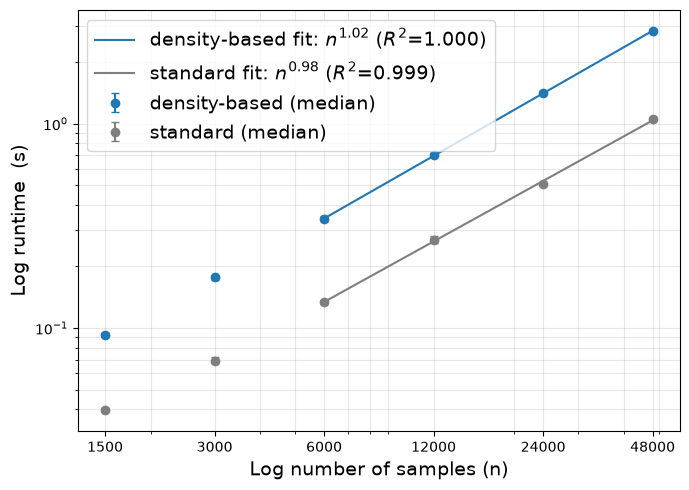

'dbmapper_scaling_fast_hdbscan.png'

In [25]:
from matplotlib.ticker import NullFormatter
def _scaling_figure(cname, results, fits):
    slug = cname.replace(" ", "_").replace("-", "_")
    out = OUT_PNG_TEMPLATE.format(slug=slug)
    labels = {True: "density-based", False: "standard"}
    colors = {True: "tab:blue", False: "tab:grey"}
    ns = np.array(SIZES, float)

    fig, ax = plt.subplots(figsize=(7, 5))
    for m in (True, False):
        med = np.array([np.median(results[m][n]) for n in SIZES])
        lo = np.array([np.min(results[m][n]) for n in SIZES])
        hi = np.array([np.max(results[m][n]) for n in SIZES])
        ax.errorbar(ns, med, yerr=[med - lo, hi - med], fmt="o",
                    color=colors[m], capsize=3, label=f"{labels[m]} (median)")
        alpha, C, r2, _ = fits[m]
        xx = np.linspace(FIT_MIN_N, ns.max(), 100)
        ax.plot(xx, C * xx ** alpha, "-", color=colors[m],
                label=fr"{labels[m]} fit: $n^{{{alpha:.2f}}}$ ($R^2$={r2:.3f})")
    ax.set_xscale("log"); ax.set_yscale("log");
    ax.set_xlabel("Log number of samples (n)", fontsize=14)
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set_xticks(SIZES, SIZES)
    ax.set_ylabel("Log runtime  (s)", fontsize=14)
    #ax.set_title(f"Mapper runtime scaling -- {cname}")
    ax.legend(frameon=True, fontsize=14, loc='upper left')
    ax.grid(True, which="both", alpha=0.3)
    fig.tight_layout()
    fig.savefig(out, dpi=300)
    print(f"  saved {out}")
    plt.show()
    return out


_scaling_figure(cname, results, fits)